In [2]:
import pointpats
import folium
import h3
import contextily as cx
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from matplotlib import patches
from sklearn import cluster

url = "http://data.insideairbnb.com/czech-republic/prague/prague/2024-12-22/data/listings.csv.gz"

prag_Airbnb = pd.read_csv(url, index_col="id")
prag_Airbnb = gpd.GeoDataFrame(prag_Airbnb, geometry=gpd.points_from_xy(prag_Airbnb["longitude"], prag_Airbnb["latitude"]), crs=4326)
prag_Airbnb = prag_Airbnb.to_crs(epsg=5514)
prag_Airbnb.sample(n=8)

,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,geometry
id,,,,,,,,,,,,,,,,,,,,,
850782430980589900,https://www.airbnb.com/rooms/850782430980589900,20241222060024,2024-12-22,city scrape,Stylish&Comfort Apartman 3 min Charles Bridge,Enjoy the perfect blend of tranquility and mod...,"Malá Strana, where our accommodation is locate...",https://a0.muscache.com/pictures/miso/Hosting-...,125966354,https://www.airbnb.com/users/show/125966354,...,4.89,4.67,NaN,t,4,4,0,0,5.46,POINT (-743788.753 -1042704.417)
1019695149196953241,https://www.airbnb.com/rooms/1019695149196953241,20241222060024,2024-12-22,city scrape,Podkrovní byt ve městě Praha 5,"Beautiful, bright, loft apartment in Prague 5 ...",NaN,https://a0.muscache.com/pictures/airflow/Hosti...,544154231,https://www.airbnb.com/users/show/544154231,...,4.84,4.95,NaN,t,2,2,0,0,3.02,POINT (-744019.375 -1044547.983)
31467684,https://www.airbnb.com/rooms/31467684,20241222060024,2024-12-22,city scrape,Central Prague Crown Apartment,This newly renovated apartment is situated in ...,The apartment is unique for its location and a...,https://a0.muscache.com/pictures/a40eae9e-d992...,233003906,https://www.airbnb.com/users/show/233003906,...,4.92,4.88,NaN,f,4,4,0,0,2.15,POINT (-742158.547 -1043486.976)
17529107,https://www.airbnb.com/rooms/17529107,20241222060024,2024-12-22,city scrape,AMAZING Flat next to Prague Main Train station,"New, comfortable apartment is located next to ...","The flat is in centre, near Wenceslas square. ...",https://a0.muscache.com/pictures/2de95ad7-4576...,118863641,https://www.airbnb.com/users/show/118863641,...,4.97,4.91,NaN,f,1,1,0,0,0.37,POINT (-742248.229 -1043613.857)
1223263083773147579,https://www.airbnb.com/rooms/1223263083773147579,20241222060024,2024-12-22,city scrape,Bedroom with Terrace Access & Garden View,"My cat, Indi, and I are welcoming hosts who sh...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,20279105,https://www.airbnb.com/users/show/20279105,...,5.00,5.00,NaN,f,2,1,1,0,0.24,POINT (-742236.642 -1044689.475)
998234533686288297,https://www.airbnb.com/rooms/998234533686288297,20241222060024,2024-12-22,city scrape,Luxury gem near Kampa Park,Welcome to our exquisite apartment nestled in ...,"Cosy and quiet apartment at Lesser Town, surro...",https://a0.muscache.com/pictures/miso/Hosting-...,8407384,https://www.airbnb.com/users/show/8407384,...,4.89,4.85,NaN,t,8,8,0,0,3.25,POINT (-743958.975 -1043516.024)
18063331,https://www.airbnb.com/rooms/18063331,20241222060024,2024-12-22,city scrape,Woody Apartment,Woody is spacy and comfortable place for a fam...,NaN,https://a0.muscache.com/pictures/25ffe937-eb13...,47725871,https://www.airbnb.com/users/show/47725871,...,4.95,4.81,NaN,f,12,4,8,0,1.08,POINT (-742004.444 -1042639.218)
1186344405258857425,https://www.airbnb.com/rooms/1186344405258857425,20241222060024,2024-12-22,city scrape,Terrace Top Haven,A unique combination of a spaciousness and mi...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,585494424,https://www.airbnb.com/users/show/585494424,...,4.00,4.00,NaN,f,1,1,0,0,0.70,POINT (-740287.154 -1041495.79)


In [3]:
prag_Airbnb[["x", "y"]] = prag_Airbnb.get_coordinates()

(array([-760000., -755000., -750000., -745000., -740000., -735000.,
        -730000., -725000., -720000.]),
 [Text(-760000.0, 0, '−760000'),
  Text(-755000.0, 0, '−755000'),
  Text(-750000.0, 0, '−750000'),
  Text(-745000.0, 0, '−745000'),
  Text(-740000.0, 0, '−740000'),
  Text(-735000.0, 0, '−735000'),
  Text(-730000.0, 0, '−730000'),
  Text(-725000.0, 0, '−725000'),
  Text(-720000.0, 0, '−720000')])

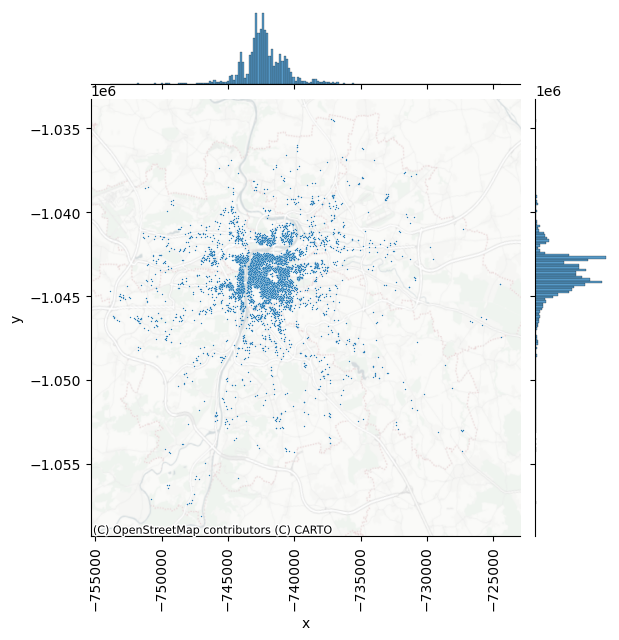

In [4]:
axs = sns.jointplot(x="x", y="y", data=prag_Airbnb, s=1)
cx.add_basemap(
    ax = axs.ax_joint, crs=prag_Airbnb.crs, source="CartoDB Positron No Labels"
)
plt.xticks(rotation=90)

In [5]:
for x, y in zip(prag_Airbnb["x"], prag_Airbnb["y"]):
    prag_Airbnb["h3_address"] = h3.latlng_to_cell(y, x, 9)

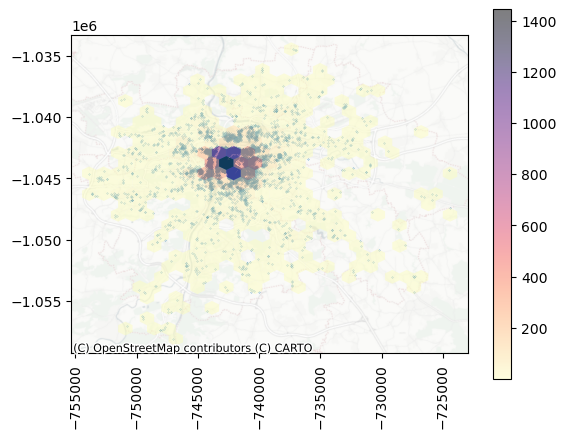

In [6]:
fig, ax = plt.subplots()
prag_Airbnb.plot(ax=ax, markersize=0.05)
hb = ax.hexbin(
    prag_Airbnb["x"],
    prag_Airbnb["y"],
    gridsize=25,
    linewidths=0,
    alpha=0.5,
    cmap="magma_r",
    mincnt=1,
)

cx.add_basemap(
    ax=ax,
    crs=prag_Airbnb.crs,
    source="CartoDB Positron No Labels",
)
plt.colorbar(hb)
plt.xticks(rotation=90);

/Users/christopherchan/Proj/SPDS_KARLOVA/spatial-data-science-in-python-chrischank/.pixi/envs/default/lib/python3.14/site-packages/pointpats/kde.py:161: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(x_mesh, y_mesh, z, levels=levels, **kwargs)


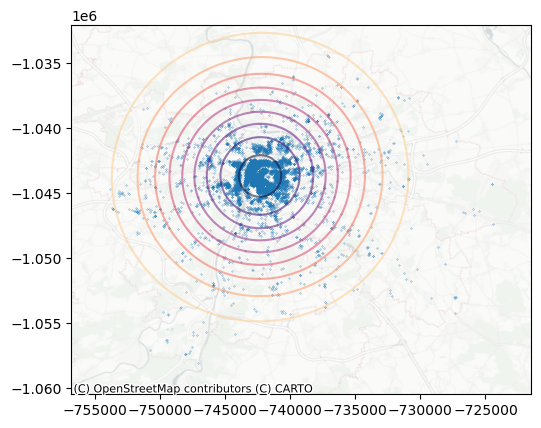

In [7]:
# KDE
fig, ax = plt.subplots()
prag_Airbnb.plot(ax=ax, markersize=0.05)
pointpats.plot_density(
    prag_Airbnb,
    bandwidth=5000,
    levels=9,
    alpha=0.55,
    cmap="magma_r",
    linewidth=1,
    ax=ax
)
cx.add_basemap(
    ax=ax,
    crs=prag_Airbnb.crs,
    source="Carto DB Positron No Labels"
)

Airbnb patterns in praha seems to be in very regular concentric circles

In [8]:
# Centograph
mean_centre = pointpats.centrography.mean_center(prag_Airbnb)
med_centre = pointpats.centrography.euclidean_median(prag_Airbnb)

In [9]:
prag_Airbnb.columns

Index(['listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar

In [10]:
prag_Airbnb["price"] = prag_Airbnb["price"].str.replace("$", "").str.replace(",", "").astype("float32")

In [11]:
prag_Airbnb[["price", "review_scores_rating"]].describe()

,price,review_scores_rating
count,8.851000e+03,8990.000000
mean,5.076011e+03,4.727165
std,2.516177e+04,0.355862
min,2.260000e+02,1.000000
25%,2.086000e+03,4.650000
50%,3.143000e+03,4.820000
75%,4.900500e+03,4.930000
max,1.926446e+06,5.000000


In [12]:
weighted_price_mean = pointpats.centrography.weighted_mean_center(
    prag_Airbnb, prag_Airbnb["price"]
)
weighted_rating_mean = pointpats.centrography.weighted_mean_center(
    prag_Airbnb, prag_Airbnb["review_scores_rating"]
)
median_center = pointpats.centrography.euclidean_median(prag_Airbnb)
mean_center = pointpats.centrography.mean_center(prag_Airbnb)


ellipse_Airbnb = pointpats.centrography.ellipse(
    prag_Airbnb
)

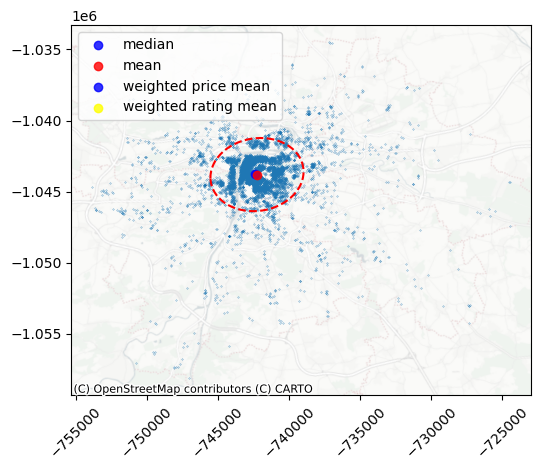

In [13]:
fig, ax = plt.subplots()
prag_Airbnb.plot(ax=ax, markersize=0.05)

ax.scatter(*median_center.xy, color="blue", marker="o", label="median", alpha=0.8)
ax.scatter(*mean_center.xy, color="red", marker="o", label="mean", alpha=0.8)
ax.scatter(*weighted_price_mean.xy, color="blue", marker="o", label="weighted price mean", alpha=0.8)
ax.scatter(*weighted_rating_mean.xy, color="yellow", marker="o", label="weighted rating mean", alpha=0.8)
gpd.GeoSeries([ellipse_Airbnb.boundary], crs=prag_Airbnb.crs).plot(
    ax=ax,
    color="red",
    linestyle="--"
)


ax.legend(loc="upper left")

cx.add_basemap(
    ax=ax,
    crs=prag_Airbnb.crs,
    source="CartoDB Positron No Labels"
)
plt.xticks(rotation=45);

In [14]:
# Quadrat
qstat = pointpats.QStatistic(prag_Airbnb, nx=6, ny=6)
print(qstat.chi2, qstat.chi2_pvalue)

189130.7357236378 0.0


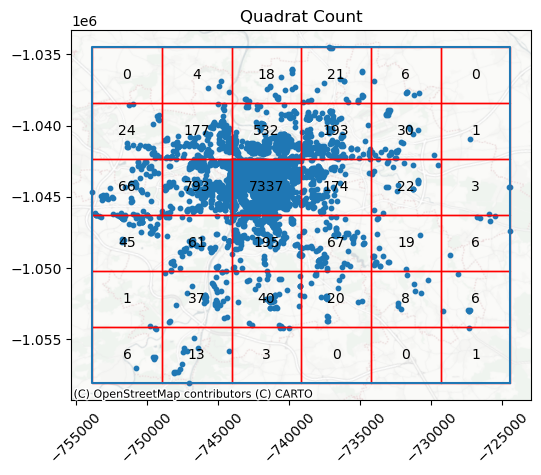

In [15]:
ax = qstat.plot()
cx.add_basemap(
    ax=ax,
    crs=prag_Airbnb.crs,
    source="CartoDB Positron No Labels",
)
plt.xticks(rotation=45);

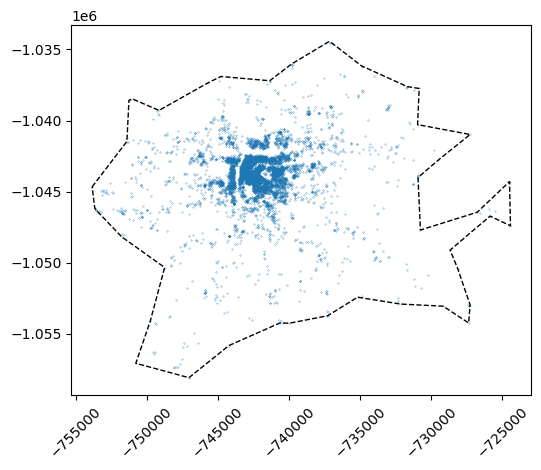

In [21]:
concave_hull = prag_Airbnb.dissolve().concave_hull(ratio=.2)

ax = prag_Airbnb.plot(markersize=0.05)
concave_hull.plot(
    ax=ax,
    facecolor="none",
    edgecolor="k",
    linestyle="--"
)
plt.xticks(rotation=45);

In [17]:
g_test = pointpats.distance_statistics.g_test(
    prag_Airbnb,
    support=200,
    keep_simulations=True,
    hull=concave_hull.item(),
    n_simulations=99
)

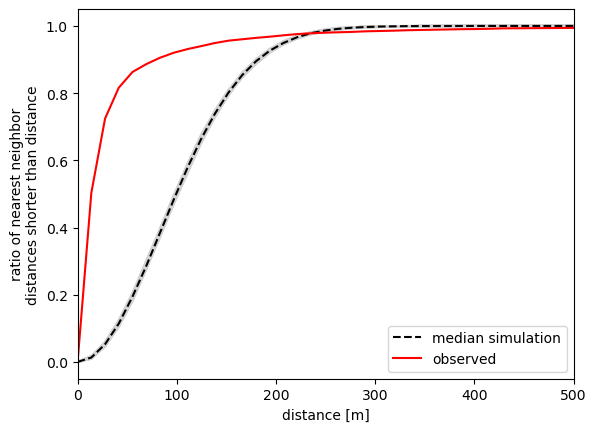

In [18]:
f, ax = plt.subplots()
ax.plot(g_test.support, g_test.simulations.T, color="lightgrey")
ax.plot(
    g_test.support,
    np.median(g_test.simulations, axis=0),
    color="k",
    label="median simulation",
    linestyle="--",
)
ax.plot(g_test.support, g_test.statistic, label="observed", color="red")
ax.set_xlabel("distance [m]")
ax.set_ylabel(
    "ratio of nearest neighbor\n"
    "distances shorter than distance"
)
ax.legend()
ax.set_xlim(0, 500);